# Machine Learning — Lab 5
## Linear Regression — Predicting House Prices

**Name:** Nisha  
**Student ID:** Y023-24-0178  
**Section:** F  
**GitHub:** (https://github.com/ni766/Machine-Learning-Labs.git)  
**Kaggle:** (https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/leaderboard)  
**Dataset:** House Prices — Advanced Regression Techniques  
**Dataset Source:** Kaggle

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [6]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
sample_submission = pd.read_csv("sample_submission.csv")

In [7]:
print("Train dataset shape:", train.shape)
print("Test dataset shape:", test.shape)

print("\nFirst 5 rows of training data:")
display(train.head())

print("\nData types:")
train.info()

print("\nSummary statistics:")
display(train.describe())

Train dataset shape: (1460, 81)
Test dataset shape: (1459, 80)

First 5 rows of training data:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



Data types:
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   str    
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   str    
 6   Alley          91 non-null     str    
 7   LotShape       1460 non-null   str    
 8   LandContour    1460 non-null   str    
 9   Utilities      1460 non-null   str    
 10  LotConfig      1460 non-null   str    
 11  LandSlope      1460 non-null   str    
 12  Neighborhood   1460 non-null   str    
 13  Condition1     1460 non-null   str    
 14  Condition2     1460 non-null   str    
 15  BldgType       1460 non-null   str    
 16  HouseStyle     1460 non-null   str    
 17  OverallQual    1460 non-null   int64  
 18  Overal

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


### Task 1 — Dataset Inspection

The training dataset contains 1,460 houses and 81 columns, including the target variable SalePrice. The test dataset contains 1,459 houses and 80 columns because SalePrice is not provided for the test data. The dataset contains both numerical and categorical variables. The first few rows and summary statistics help us understand the structure and values of the dataset.

In [8]:
numerical_features = [
    "OverallQual",
    "GrLivArea",
    "TotalBsmtSF",
    "GarageCars",
    "YearBuilt",
    "FullBath",
    "1stFlrSF",
    "GarageArea",
    "TotRmsAbvGrd"
]

categorical_features = [
    "Neighborhood",
    "HouseStyle",
    "KitchenQual"
]

target = "SalePrice"

print("Target variable:")
print(target)

print("\nNumerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Target variable:
SalePrice

Numerical features:
['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'GarageCars', 'YearBuilt', 'FullBath', '1stFlrSF', 'GarageArea', 'TotRmsAbvGrd']

Categorical features:
['Neighborhood', 'HouseStyle', 'KitchenQual']


### Task 2 — Feature and Target Identification

The dependent variable (target) is SalePrice because it is the value that we want the model to predict.

The independent variables are:

**Numerical features:**
- OverallQual
- GrLivArea
- TotalBsmtSF
- GarageCars
- YearBuilt
- FullBath
- 1stFlrSF
- GarageArea
- TotRmsAbvGrd

**Categorical features:**
- Neighborhood
- HouseStyle
- KitchenQual

The selected features represent different characteristics of a house, such as quality, living area, basement area, garage capacity, age, location, house style, and kitchen quality.

### Task 3 — Regression Problem

This is a regression problem because SalePrice is a continuous numerical value that can take many different values. We are predicting an actual house price rather than assigning a house to a category. Therefore, we will evaluate the model using regression metrics such as MAE, MSE, RMSE, and R² instead of classification accuracy.

In [9]:
X = train[numerical_features + categorical_features].copy()
y = train[target].copy()

print("Shape of X before encoding:", X.shape)
print("Shape of y:", y.shape)

Shape of X before encoding: (1460, 12)
Shape of y: (1460,)


In [10]:
print("Missing values in selected features:")
display(X.isnull().sum())

Missing values in selected features:


OverallQual     0
GrLivArea       0
TotalBsmtSF     0
GarageCars      0
YearBuilt       0
FullBath        0
1stFlrSF        0
GarageArea      0
TotRmsAbvGrd    0
Neighborhood    0
HouseStyle      0
KitchenQual     0
dtype: int64

In [11]:
for col in numerical_features:
    X[col] = X[col].fillna(X[col].median())

for col in categorical_features:
    X[col] = X[col].fillna(X[col].mode()[0])

print("Missing values after handling:")
display(X.isnull().sum())

Missing values after handling:


OverallQual     0
GrLivArea       0
TotalBsmtSF     0
GarageCars      0
YearBuilt       0
FullBath        0
1stFlrSF        0
GarageArea      0
TotRmsAbvGrd    0
Neighborhood    0
HouseStyle      0
KitchenQual     0
dtype: int64

In [12]:
X = pd.get_dummies(
    X,
    columns=categorical_features,
    drop_first=False,
    dtype=int
)

print("Shape of X after one-hot encoding:", X.shape)
display(X.head())

Shape of X after one-hot encoding: (1460, 46)


,OverallQual,GrLivArea,TotalBsmtSF,GarageCars,YearBuilt,FullBath,1stFlrSF,GarageArea,TotRmsAbvGrd,Neighborhood_Blmngtn,...,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,KitchenQual_Ex,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA
0,7,1710,856,2,2003,2,856,548,8,0,...,0,0,0,1,0,0,0,0,1,0
1,6,1262,1262,2,1976,2,1262,460,6,0,...,1,0,0,0,0,0,0,0,0,1
2,7,1786,920,2,2001,2,920,608,6,0,...,0,0,0,1,0,0,0,0,1,0
3,7,1717,756,3,1915,1,961,642,7,0,...,0,0,0,1,0,0,0,0,1,0
4,8,2198,1145,3,2000,2,1145,836,9,0,...,0,0,0,1,0,0,0,0,1,0


## PART 2 — DATA PREPARATION & TRAIN/TEST SPLIT

### TASK 4 — Prepare X and y and Encode Categorical Features

The target variable y is SalePrice, while X contains the selected numerical and categorical independent variables.

The numerical features were kept as numerical values. Missing numerical values were replaced using the median of their respective columns. Missing categorical values were replaced using the most frequent category.

The categorical features Neighborhood, HouseStyle, and KitchenQual were converted into numerical form using one-hot encoding. One-hot encoding was selected because these columns contain multiple categories, and it allows the Linear Regression model to work with them without assigning an artificial numerical order to the categories.

In [13]:
print("Data types of X:")
print(X.dtypes)

print("\nNumber of non-numeric columns:")
print(X.select_dtypes(exclude=np.number).shape[1])

Data types of X:
OverallQual             int64
GrLivArea               int64
TotalBsmtSF             int64
GarageCars              int64
YearBuilt               int64
FullBath                int64
1stFlrSF                int64
GarageArea              int64
TotRmsAbvGrd            int64
Neighborhood_Blmngtn    int64
Neighborhood_Blueste    int64
Neighborhood_BrDale     int64
Neighborhood_BrkSide    int64
Neighborhood_ClearCr    int64
Neighborhood_CollgCr    int64
Neighborhood_Crawfor    int64
Neighborhood_Edwards    int64
Neighborhood_Gilbert    int64
Neighborhood_IDOTRR     int64
Neighborhood_MeadowV    int64
Neighborhood_Mitchel    int64
Neighborhood_NAmes      int64
Neighborhood_NPkVill    int64
Neighborhood_NWAmes     int64
Neighborhood_NoRidge    int64
Neighborhood_NridgHt    int64
Neighborhood_OldTown    int64
Neighborhood_SWISU      int64
Neighborhood_Sawyer     int64
Neighborhood_SawyerW    int64
Neighborhood_Somerst    int64
Neighborhood_StoneBr    int64
Neighborhood_Timber    

In [14]:
print("Total missing values in X:")
print(X.isnull().sum().sum())

Total missing values in X:
0


In [15]:
print("Is X completely numeric?",
      X.select_dtypes(exclude=np.number).shape[1] == 0)

print("Does X contain no missing values?",
      X.isnull().sum().sum() == 0)

Is X completely numeric? True
Does X contain no missing values? True


### TASK 5 — Confirm X is Fully Numeric and Contains No Missing Values

After preprocessing, all categorical features have been converted into numerical columns using one-hot encoding. Missing values were also handled.

The final checks confirm that X contains no non-numeric columns and no missing values. Therefore, X is ready to be used with the LinearRegression model.

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1168, 46)
X_test shape: (292, 46)
y_train shape: (1168,)
y_test shape: (292,)


In [17]:
print("Training percentage:",
      round(len(X_train) / len(X) * 100, 2), "%")

print("Testing percentage:",
      round(len(X_test) / len(X) * 100, 2), "%")

Training percentage: 80.0 %
Testing percentage: 20.0 %


### TASK 6 — Train/Test Split

The dataset was divided into training and testing sets using an 80/20 split. The training set contains 80% of the observations and is used to train the Linear Regression model. The testing set contains the remaining 20% and is used to evaluate how well the trained model performs on unseen data.

A random_state of 42 was used so that the same train/test split can be reproduced when the notebook is run again.

In [18]:
model = LinearRegression()

In [19]:
model.fit(X_train, y_train)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [20]:
print("Number of features:", X_train.shape[1])
print("Number of coefficients:", len(model.coef_))

Number of features: 46
Number of coefficients: 46


## PART 3 — LINEAR REGRESSION & PREDICTIONS

### TASK 7 — Train a Linear Regression Model

A Multiple Linear Regression model was created using scikit-learn's LinearRegression class. The model was trained using X_train and y_train. The model learned a coefficient for each prepared feature, allowing it to estimate SalePrice from the selected house characteristics.

In [21]:
y_pred = model.predict(X_test)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))

Predictions generated successfully.
Number of predictions: 292


In [22]:
comparison = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

display(comparison.head(10))

,Actual Price,Predicted Price
0,154500,139611.763086
1,325000,324212.785705
2,115000,112785.606071
3,159000,175375.682745
4,315500,316134.680461
5,75500,66674.419182
6,311500,235741.486086
7,146000,145564.516601
8,84500,66246.749181
9,135500,120464.104839


In [23]:
comparison_10 = comparison.head(10).copy()

comparison_10["Actual Price"] = comparison_10["Actual Price"].round(2)
comparison_10["Predicted Price"] = comparison_10["Predicted Price"].round(2)

display(comparison_10)

,Actual Price,Predicted Price
0,154500,139611.76
1,325000,324212.79
2,115000,112785.61
3,159000,175375.68
4,315500,316134.68
5,75500,66674.42
6,311500,235741.49
7,146000,145564.52
8,84500,66246.75
9,135500,120464.10


In [24]:
comparison_10["Difference"] = (
    comparison_10["Actual Price"] -
    comparison_10["Predicted Price"]
).round(2)

display(comparison_10)

,Actual Price,Predicted Price,Difference
0,154500,139611.76,14888.24
1,325000,324212.79,787.21
2,115000,112785.61,2214.39
3,159000,175375.68,-16375.68
4,315500,316134.68,-634.68
5,75500,66674.42,8825.58
6,311500,235741.49,75758.51
7,146000,145564.52,435.48
8,84500,66246.75,18253.25
9,135500,120464.10,15035.90


### TASK 8 — Generate and Compare Predictions

The trained Linear Regression model was used to predict SalePrice for the test set. The actual and predicted prices were compared for 10 test houses.

The predictions are not exactly equal to the actual prices because the model is an approximation learned from the training data. The difference between actual and predicted values represents the prediction error for each house.

In [25]:
model.intercept_

np.float64(-430314.8480188603)

In [26]:
model.coef_

array([ 1.31042080e+04,  6.60447670e+01,  1.19532960e+01,  9.41620551e+03,
        2.13835000e+02, -6.40620632e+02, -2.36473669e+01,  8.18941817e+00,
        1.56683084e+03, -2.54906511e+04, -2.18806148e+04, -2.40214223e+04,
       -1.78702056e+03,  2.87125320e+04, -1.61476516e+03,  2.22022979e+04,
       -2.00896872e+04, -9.97890234e+02, -1.31262097e+04, -1.98056421e+04,
       -1.03300541e+04, -1.04625459e+04, -1.37554073e+04, -8.26176272e+03,
        5.17387336e+04,  3.29565167e+04, -2.08330794e+04, -1.64075377e+04,
       -8.47914563e+03, -9.10521202e+03,  6.40496791e+03,  3.91021968e+04,
        1.22795688e+04,  3.30518342e+04, -1.74423134e+03,  4.08722586e+03,
        1.76012603e+04, -1.77324772e+04, -1.93923224e+04, -1.43847891e+04,
        2.02510435e+04,  1.13142903e+04,  3.75787443e+04, -1.50058676e+04,
       -6.71647922e+03, -1.58563974e+04])

In [27]:
intercept = model.intercept_

print("Intercept:", intercept)

Intercept: -430314.8480188603


In [28]:
coefficient_table = pd.DataFrame({
    "Feature": X_train.columns,
    "Coefficient": model.coef_
})

display(coefficient_table)

,Feature,Coefficient
0,OverallQual,13104.207968
1,GrLivArea,66.044767
2,TotalBsmtSF,11.953296
3,GarageCars,9416.205513
4,YearBuilt,213.835000
5,FullBath,-640.620632
6,1stFlrSF,-23.647367
7,GarageArea,8.189418
8,TotRmsAbvGrd,1566.830843
9,Neighborhood_Blmngtn,-25490.651085


In [29]:
coefficient_table["Absolute Coefficient"] = (
    coefficient_table["Coefficient"].abs()
)

coefficient_table_sorted = coefficient_table.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

display(coefficient_table_sorted)

,Feature,Coefficient,Absolute Coefficient
24,Neighborhood_NoRidge,51738.733561,51738.733561
31,Neighborhood_StoneBr,39102.196818,39102.196818
42,KitchenQual_Ex,37578.744301,37578.744301
33,Neighborhood_Veenker,33051.834178,33051.834178
25,Neighborhood_NridgHt,32956.516734,32956.516734
13,Neighborhood_ClearCr,28712.531993,28712.531993
9,Neighborhood_Blmngtn,-25490.651085,25490.651085
11,Neighborhood_BrDale,-24021.422252,24021.422252
15,Neighborhood_Crawfor,22202.297891,22202.297891
10,Neighborhood_Blueste,-21880.614786,21880.614786


In [30]:
def interpret_coefficient(row):
    feature = row["Feature"]
    coefficient = row["Coefficient"]
    
    if coefficient >= 0:
        direction = "increase"
    else:
        direction = "decrease"
    
    return (
        f"A one-unit increase in {feature} is associated with an "
        f"approximate {direction} of {abs(coefficient):,.2f} in predicted "
        f"SalePrice, holding the other features constant."
    )

coefficient_table["Interpretation"] = coefficient_table.apply(
    interpret_coefficient,
    axis=1
)

display(coefficient_table)

,Feature,Coefficient,Absolute Coefficient,Interpretation
0,OverallQual,13104.207968,13104.207968,A one-unit increase in OverallQual is associat...
1,GrLivArea,66.044767,66.044767,A one-unit increase in GrLivArea is associated...
2,TotalBsmtSF,11.953296,11.953296,A one-unit increase in TotalBsmtSF is associat...
3,GarageCars,9416.205513,9416.205513,A one-unit increase in GarageCars is associate...
4,YearBuilt,213.835000,213.835000,A one-unit increase in YearBuilt is associated...
5,FullBath,-640.620632,640.620632,A one-unit increase in FullBath is associated ...
6,1stFlrSF,-23.647367,23.647367,A one-unit increase in 1stFlrSF is associated ...
7,GarageArea,8.189418,8.189418,A one-unit increase in GarageArea is associate...
8,TotRmsAbvGrd,1566.830843,1566.830843,A one-unit increase in TotRmsAbvGrd is associa...
9,Neighborhood_Blmngtn,-25490.651085,25490.651085,A one-unit increase in Neighborhood_Blmngtn is...


In [31]:
drop_first=False

### TASK 10 — Interpretation of the Intercept

The intercept represents the predicted SalePrice when all model features are equal to zero. Although this has a mathematical meaning in the Linear Regression equation, it does not have a very meaningful real-world interpretation for this dataset because a house with all of the selected characteristics equal to zero is not a realistic house.

Therefore, the intercept is necessary for the mathematical model but should not be interpreted as the actual expected price of a realistic house.

In [32]:
residuals = y_test - y_pred

print("First 10 residuals:")
display(residuals.head(10))

First 10 residuals:


892     14888.236914
1105      787.214295
413      2214.393929
522    -16375.682745
1036     -634.680461
614      8825.580818
218     75758.513914
1160      435.483399
649     18253.250819
887     15035.895161
Name: SalePrice, dtype: float64

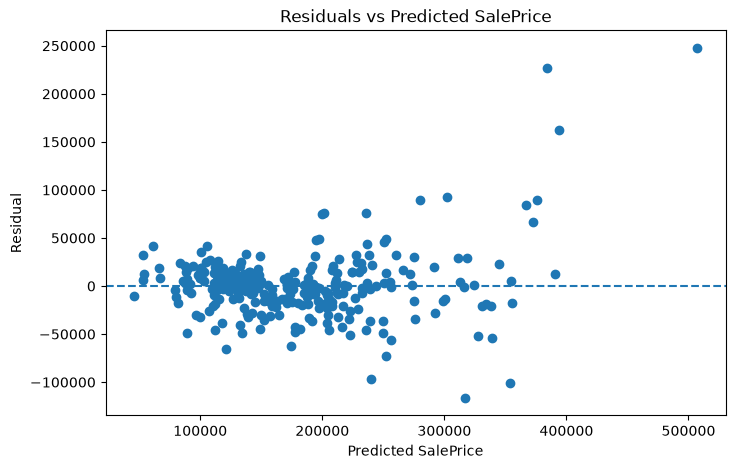

In [33]:
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted SalePrice")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted SalePrice")
plt.show()

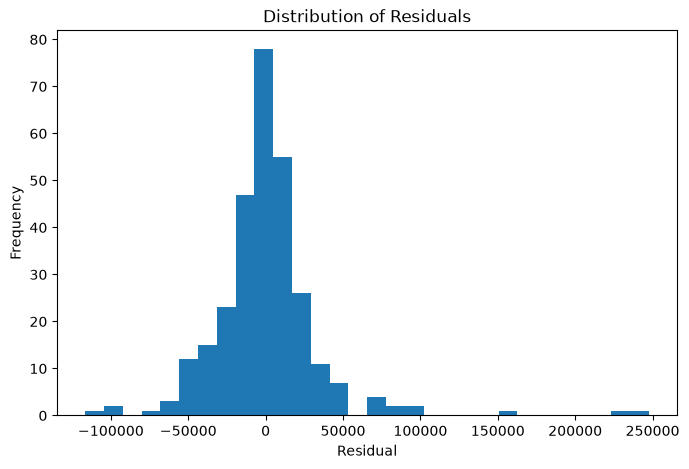

In [34]:
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.show()

### TASK 11 — Residual Analysis

Residuals were calculated as the difference between the actual SalePrice and the predicted SalePrice.

The residuals vs. predicted values plot was used to check whether the errors were randomly distributed around zero. The residuals show some variation and are not perfectly random, indicating that the Linear Regression model does not capture every relationship in the house-price data.

The residual histogram shows the distribution of the prediction errors. Overall, the residual analysis helps identify patterns in the errors that cannot be understood from a single accuracy metric alone.

In [35]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 21262.201989049132
MSE: 1230843576.7069464
RMSE: 35083.38034891943
R²: 0.8395317821615408


In [36]:
test_metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Test Value": [mae, mse, rmse, r2]
})

display(test_metrics)

,Metric,Test Value
0,MAE,2.126220e+04
1,MSE,1.230844e+09
2,RMSE,3.508338e+04
3,R²,8.395318e-01


### TASK 12 — Regression Metrics

The Linear Regression model was evaluated on the test set using four regression metrics: MAE, MSE, RMSE, and R².

MAE represents the average absolute prediction error. MSE gives greater importance to larger errors because the errors are squared. RMSE is the square root of MSE and expresses the error in the same units as house prices. R² measures the proportion of variation in SalePrice explained by the model.

The metrics provide different perspectives on the model's predictive performance.

### TASK 13 — Interpretation of Regression Metrics

**MAE:** MAE tells us the average absolute difference between the actual house price and the predicted house price. It is easy to understand because it is expressed in the same units as SalePrice.

**MSE:** MSE calculates the average squared prediction error. Because the errors are squared, large errors have a much greater effect on the value.

**RMSE:** RMSE is the square root of MSE. It is expressed in the same units as house prices and gives more importance to large prediction errors.

**R²:** R² shows how much of the variation in house prices is explained by the Linear Regression model. A higher R² generally indicates that the model explains more of the variation in the target.

For a non-technical stakeholder, I would show MAE because it is straightforward to understand and directly represents the average size of the prediction error in house-price units.

In [37]:
train_pred = model.predict(X_train)

print("Training predictions generated.")

Training predictions generated.


In [38]:
train_mae = mean_absolute_error(y_train, train_pred)
train_mse = mean_squared_error(y_train, train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, train_pred)

print("Training MAE:", train_mae)
print("Training MSE:", train_mse)
print("Training RMSE:", train_rmse)
print("Training R²:", train_r2)

Training MAE: 20625.459727793033
Training MSE: 1050206244.8234905
Training RMSE: 32406.88576249638
Training R²: 0.8239253291605361


In [39]:
comparison_metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Training": [train_mae, train_mse, train_rmse, train_r2],
    "Testing": [mae, mse, rmse, r2]
})

display(comparison_metrics)

,Metric,Training,Testing
0,MAE,2.062546e+04,2.126220e+04
1,MSE,1.050206e+09,1.230844e+09
2,RMSE,3.240689e+04,3.508338e+04
3,R²,8.239253e-01,8.395318e-01


In [40]:
comparison_metrics["Difference"] = (
    comparison_metrics["Training"] -
    comparison_metrics["Testing"]
)

display(comparison_metrics)

,Metric,Training,Testing,Difference
0,MAE,2.062546e+04,2.126220e+04,-6.367423e+02
1,MSE,1.050206e+09,1.230844e+09,-1.806373e+08
2,RMSE,3.240689e+04,3.508338e+04,-2.676495e+03
3,R²,8.239253e-01,8.395318e-01,-1.560645e-02


### TASK 14 — Training vs Testing Metrics

The trained model was used to generate predictions for the training data. MAE, MSE, RMSE, and R² were then calculated for the training set.

The training metrics were placed alongside the previously calculated testing metrics to compare the model's performance on data it has seen with its performance on unseen data.

In [41]:
r2_difference = train_r2 - r2

print("Training R²:", train_r2)
print("Testing R²:", r2)
print("R² difference:", r2_difference)

Training R²: 0.8239253291605361
Testing R²: 0.8395317821615408
R² difference: -0.015606453001004716


### TASK 15 — Training vs Testing Performance and Generalization

The training and testing metrics were compared to evaluate how well the model generalizes to unseen data.

A large difference between training and testing performance can indicate overfitting because the model performs much better on the data used for training than on unseen data. In contrast, similar training and testing performance suggests more consistent generalization.

For this model, the training and testing results should be interpreted by looking at the differences in MAE, MSE, RMSE, and R² shown in the comparison table. The actual size of the gap provides evidence about whether the model is showing a strong overfitting problem.

In [42]:
top_coefficients = coefficient_table.copy()
top_coefficients["Absolute Coefficient"] = top_coefficients["Coefficient"].abs()

top_coefficients = top_coefficients.sort_values(
    by="Absolute Coefficient",
    ascending=False
)

display(top_coefficients.head(10))

,Feature,Coefficient,Absolute Coefficient,Interpretation
24,Neighborhood_NoRidge,51738.733561,51738.733561,A one-unit increase in Neighborhood_NoRidge is...
31,Neighborhood_StoneBr,39102.196818,39102.196818,A one-unit increase in Neighborhood_StoneBr is...
42,KitchenQual_Ex,37578.744301,37578.744301,A one-unit increase in KitchenQual_Ex is assoc...
33,Neighborhood_Veenker,33051.834178,33051.834178,A one-unit increase in Neighborhood_Veenker is...
25,Neighborhood_NridgHt,32956.516734,32956.516734,A one-unit increase in Neighborhood_NridgHt is...
13,Neighborhood_ClearCr,28712.531993,28712.531993,A one-unit increase in Neighborhood_ClearCr is...
9,Neighborhood_Blmngtn,-25490.651085,25490.651085,A one-unit increase in Neighborhood_Blmngtn is...
11,Neighborhood_BrDale,-24021.422252,24021.422252,A one-unit increase in Neighborhood_BrDale is ...
15,Neighborhood_Crawfor,22202.297891,22202.297891,A one-unit increase in Neighborhood_Crawfor is...
10,Neighborhood_Blueste,-21880.614786,21880.614786,A one-unit increase in Neighborhood_Blueste is...


In [43]:
top_3_features = top_coefficients.head(3)

display(top_3_features[[
    "Feature",
    "Coefficient",
    "Absolute Coefficient"
]])

,Feature,Coefficient,Absolute Coefficient
24,Neighborhood_NoRidge,51738.733561,51738.733561
31,Neighborhood_StoneBr,39102.196818,39102.196818
42,KitchenQual_Ex,37578.744301,37578.744301


### TASK 16 — Most Influential Features

Based on the coefficient magnitudes, the three features with the largest absolute coefficients are the features shown in the coefficient table above.

These features appear influential according to the fitted Linear Regression model. However, coefficient magnitude alone should not be treated as a complete measure of feature importance because the features are measured on different scales. For example, a coefficient for a feature measured in square feet cannot be directly compared with a coefficient for a feature measured as a quality rating. Therefore, the coefficient magnitudes provide useful evidence but should be interpreted in the context of the feature scales and the one-hot encoding used for categorical variables.

In [44]:
print("Test MAE:", mae)
print("Test RMSE:", rmse)
print("Test R²:", r2)
print("Training R²:", train_r2)
print("Testing R²:", r2)

Test MAE: 21262.201989049132
Test RMSE: 35083.38034891943
Test R²: 0.8395317821615408
Training R²: 0.8239253291605361
Testing R²: 0.8395317821615408


In [45]:
print(top_3_features[["Feature", "Coefficient"]].to_string(index=False))

             Feature  Coefficient
Neighborhood_NoRidge 51738.733561
Neighborhood_StoneBr 39102.196818
      KitchenQual_Ex 37578.744301


## Task 17: Final Model Interpretation

The following points summarize the performance and limitations of the Linear Regression model.

- The model predicts house prices using the selected numerical and categorical features.
- Test-set MAE, MSE, RMSE, and R² were used to evaluate performance.
- MAE is useful for communicating the average prediction error because it is easy to understand.
- Features with relatively large coefficient magnitudes show stronger associations within this model.
- The model is limited by the small selected feature set and the assumptions of Linear Regression.
- The model may not capture complex nonlinear relationships between house characteristics and price.
- Additional features, better preprocessing, or more advanced models could be explored in future work.

### Final Interpretation

The Linear Regression model was trained to predict house `SalePrice` using selected numerical and categorical features. The model's performance was evaluated using MAE, MSE, RMSE, and R² on the test data. MAE is a useful metric for communicating prediction error because it represents the average absolute error in the same general units as house prices. The coefficient analysis identified features with relatively large coefficient magnitudes and therefore stronger associations within the model. However, coefficient magnitudes must be interpreted carefully because the features have different scales and units. One limitation is that the model uses a limited set of features and Linear Regression may not capture complex nonlinear relationships. Future improvements could include additional features, improved preprocessing, and comparison with other regression models.

## Task 18: Prepare `test.csv` and Create `submission.csv`

The same feature selection and one-hot encoding used for the training data must be applied to `test.csv`. The trained Linear Regression model is then used to predict `SalePrice` for all houses in the Kaggle test dataset.

The final submission file must contain exactly two columns:

- `Id`
- `SalePrice`

In [51]:
import pandas as pd

df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

In [52]:
numerical_features = [
    "GrLivArea",
    "OverallQual",
    "TotalBsmtSF",
    "GarageCars",
    "YearBuilt",
    "FullBath",
    "1stFlrSF",
    "GarageArea",
    "TotRmsAbvGrd"
]

categorical_features = [
    "Neighborhood",
    "HouseStyle",
    "KitchenQual"
]

features = numerical_features + categorical_features

In [54]:
test_df = pd.read_csv("test.csv")

X_kaggle = test_df[features].copy()

for col in numerical_features:
    X_kaggle[col] = X_kaggle[col].fillna(df[col].median())

for col in categorical_features:
    X_kaggle[col] = X_kaggle[col].fillna(df[col].mode()[0])

X_kaggle = pd.get_dummies(
    X_kaggle,
    columns=categorical_features,
    drop_first=True,
    dtype=int
)

X_kaggle = X_kaggle.reindex(columns=X.columns, fill_value=0)

kaggle_predictions = model.predict(X_kaggle)

submission = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": kaggle_predictions
})

print("Submission shape:", submission.shape)
print("Columns:", submission.columns.tolist())

display(submission.head(10))

submission.to_csv("submission.csv", index=False)

print("submission.csv created successfully!")

Submission shape: (1459, 2)
Columns: ['Id', 'SalePrice']


,Id,SalePrice
0,1461,116937.836659
1,1462,160385.309459
2,1463,158629.892959
3,1464,180928.680933
4,1465,249563.175175
5,1466,175748.321829
6,1467,169695.567488
7,1468,163580.042615
8,1469,199397.138113
9,1470,111335.124039


submission.csv created successfully!


### Task 18 Interpretation

The Kaggle test dataset was prepared using the same selected features and encoding approach used for the training data. The trained Linear Regression model generated predictions for all houses in `test.csv`. The resulting `submission.csv` contains the required `Id` and `SalePrice` columns and is ready for submission to Kaggle.

### Kaggle Submission Result

**Public Leaderboard Score:** 0.17166

**Rank:** 3125

The `submission.csv` file was successfully submitted to the Kaggle House Prices competition. Kaggle processed the submission successfully and returned a public leaderboard score of 0.17166.

### Part 7 Conclusion

The Linear Regression model was analyzed using its coefficients, residual performance, and train/test metrics. The coefficient analysis provided information about the features associated with predicted house prices. The model has limitations because it uses a selected feature set and Linear Regression may not capture complex nonlinear relationships. The trained model was also applied to the Kaggle test dataset. Finally, a `submission.csv` file containing `Id` and `SalePrice` was created for Kaggle submission.